In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import numpy as np
import matplotlib as mpl
from matplotlib.patches import Patch

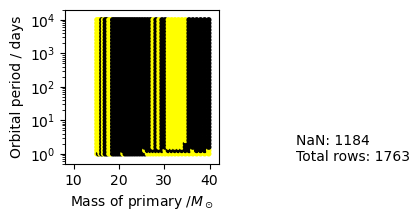

In [2]:
data = pd.read_csv("./BoOST_1.dat", sep=r"\s+")

fig, ax = plt.subplots(figsize=(3, 2))

num_false = (data['has_nan'] == True).sum()
total_rows = len(data)

case_colors = {
    True: 'black',  ## There are NaN
    False: 'yellow'  ## No NaN
}

primary_mass = data['primary_mass']
period = data['period']

colors = data['has_nan'].map(case_colors)
    
ax.scatter(primary_mass , period, color=colors, marker='.')


# Write text on the figure
ax.text(
    1.5, 0.0001,
    f'NaN: {num_false}\nTotal rows: {total_rows}',
    transform=ax.transAxes,
    verticalalignment='bottom',
    
)


ax.set_xlabel(r'Mass of primary $/M_\odot$')        # initial (ZAMS) mass
ax.set_ylabel('Orbital period / days')      # final remnant mass
# ax.set_ylim(ymin=1, ymax=10000) ##10000
# ax.set_xlim(xmin=10, xmax=40) ##40

ax.set_box_aspect(1)

# X padding (linear)
ax.set_xlim(10 - 2, 40 + 2)

# Y padding (log scale)
ax.set_yscale('log')
ax.set_ylim(1 / 2, 10000 * 2)

ax.set_xticks([10, 20, 30, 40])
ax.set_yticks([1, 10, 100, 1000, 10000])

plt.show()

ax.set_title('BoOST_run1') 


img_title = "Check_BoOST"

# save_name = output_img_dir/f"{img_title}.png"
save_name = f"{img_title}.png"

fig.savefig(save_name, bbox_inches="tight")



In [4]:
unique_vals_num_of_lines_true = sorted(data.loc[data['has_nan']== True, 'num_of_lines'].unique())
unique_vals_num_of_lines_true = [int(x) for x in unique_vals_num_of_lines_true]

print("unique_vals_num_of_lines_true", unique_vals_num_of_lines_true)

print(" ")

unique_vals_num_of_lines_false = sorted(data.loc[data['has_nan']== False, 'num_of_lines'].unique())
unique_vals_num_of_lines_false = [int(x) for x in unique_vals_num_of_lines_false]

print("unique_vals_num_of_lines_false", unique_vals_num_of_lines_false)

unique_vals_num_of_lines_true [41, 43, 44, 45, 46, 54, 69, 71, 76, 77, 78, 79, 81, 82, 83, 84, 86, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 100, 101, 103, 106, 107, 108, 109, 111, 112, 115, 127, 2705, 2959]
 
unique_vals_num_of_lines_false [2624, 2625, 2627, 2628, 2629, 2630, 2631, 2655, 2712, 2728, 2909, 2931, 3000, 3046, 3133, 3170, 3174, 3218, 3245, 3246, 3283, 3284, 3294, 3295, 3303, 3304, 3305, 3306, 3316, 3317, 3325, 3326, 3333, 3334, 3372, 3379, 3388, 3389, 3397, 3398, 3418, 3433, 3444, 3454, 3461, 3517, 3532, 3538, 3540, 3548, 3553, 3555, 3566, 3573, 3580, 3581, 3591, 3599, 3619, 3639, 3702, 3740, 3825, 3841, 3850, 3860, 3863, 3864, 3872, 3873, 3882, 3887, 3913, 3917, 3943, 4115, 4249, 4363, 4470, 4503, 4517, 4534, 4537, 4549, 4551, 4556, 4558, 4870, 5427, 5431, 5436, 5439, 5441, 5444, 5447, 5452, 5455, 5456, 5458, 5459, 5460, 5466, 5469, 5470, 5472, 5476, 5478, 5479, 5481, 5482, 5487, 5490, 5491, 5493, 5494, 5498, 5501, 5503, 5504, 5505, 5508, 5509, 5511, 5512, 5513, 5518, 5519

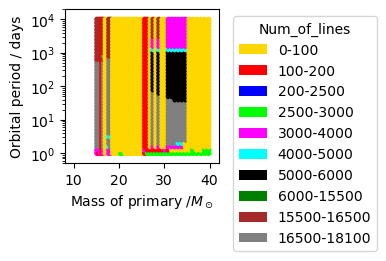

In [5]:
data = pd.read_csv("./BoOST_1.dat", sep=r"\s+")

fig, ax = plt.subplots(figsize=(3, 2))

bins = [0, 100, 200, 2500, 3000, 4000, 5000, 6000, 15500, 16500, 18100]

range_colors = [
    'gold',
    'red',
    'blue',
    'lime',
    'magenta',
    'cyan',
    'black',
    'green',
    'brown',
    'gray'
]

point_colors = pd.cut(
    data['num_of_lines'],
    bins=bins,
    labels=range_colors,
    include_lowest=True
)

ax.scatter(
    data['primary_mass'],
    data['period'],
    color=point_colors,
    marker='.'
)



legend_handles = []

for i, color in enumerate(range_colors):

    if bins[i+1] == float('inf'):
        label = f'>{bins[i]}'
    else:
        label = f'{bins[i]}-{bins[i+1]}'

    legend_handles.append(
        Patch(facecolor=color, label=label)
    )

ax.legend(
    handles=legend_handles,
    title='Num_of_lines',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

ax.set_xlabel(r'Mass of primary $/M_\odot$')        # initial (ZAMS) mass
ax.set_ylabel('Orbital period / days')      # final remnant mass
# ax.set_ylim(ymin=1, ymax=10000) ##10000
# ax.set_xlim(xmin=10, xmax=40) ##40

ax.set_box_aspect(1)

# X padding (linear)
ax.set_xlim(10 - 2, 40 + 2)

# Y padding (log scale)
ax.set_yscale('log')
ax.set_ylim(1 / 2, 10000 * 2)

ax.set_xticks([10, 20, 30, 40])
ax.set_yticks([1, 10, 100, 1000, 10000])

plt.show()

ax.set_title('BoOST_run1_num_of_lines') 


img_title = "Check_BoOST_num_of_lines"

# save_name = output_img_dir/f"{img_title}.png"
save_name = f"{img_title}.png"

fig.savefig(save_name, bbox_inches="tight")

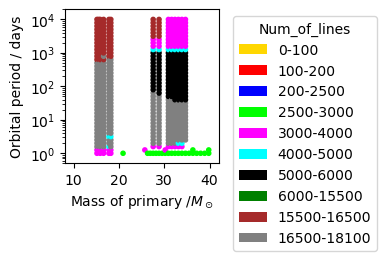

In [9]:
data = pd.read_csv("./BoOST_1.dat", sep=r"\s+")

fig, ax = plt.subplots(figsize=(3, 2))

bins = [0, 100, 200, 2500, 3000, 4000, 5000, 6000, 15500, 16500, 18100]

range_colors = [
    'gold',
    'red',
    'blue',
    'lime',
    'magenta',
    'cyan',
    'black',
    'green',
    'brown',
    'gray'
]

point_colors = pd.cut(
    data['num_of_lines'],
    bins=bins,
    labels=range_colors,
    include_lowest=True
)

mask = data['has_nan']

# False -> highlighted
ax.scatter(
    data.loc[~mask, 'primary_mass'],
    data.loc[~mask, 'period'],
    color=point_colors[~mask],
    marker='.',
    alpha=1
)

# True -> faded
ax.scatter(
    data.loc[mask, 'primary_mass'],
    data.loc[mask, 'period'],
    color=point_colors[mask],
    marker='.',
    alpha=0.00001
)


from matplotlib.patches import Patch

legend_handles = []

for i, color in enumerate(range_colors):

    if bins[i+1] == float('inf'):
        label = f'>{bins[i]}'
    else:
        label = f'{bins[i]}-{bins[i+1]}'

    legend_handles.append(
        Patch(facecolor=color, label=label)
    )

ax.legend(
    handles=legend_handles,
    title='Num_of_lines',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

ax.set_xlabel(r'Mass of primary $/M_\odot$')        # initial (ZAMS) mass
ax.set_ylabel('Orbital period / days')      # final remnant mass
# ax.set_ylim(ymin=1, ymax=10000) ##10000
# ax.set_xlim(xmin=10, xmax=40) ##40

ax.set_box_aspect(1)

# X padding (linear)
ax.set_xlim(10 - 2, 40 + 2)

# Y padding (log scale)
ax.set_yscale('log')
ax.set_ylim(1 / 2, 10000 * 2)

ax.set_xticks([10, 20, 30, 40])
ax.set_yticks([1, 10, 100, 1000, 10000])

plt.show()

ax.set_title('BoOST_run1_num_of_lines_with_mask_true_faded') 


img_title = "Check_BoOST_num_of_lines_with_mask_true_faded"

# save_name = output_img_dir/f"{img_title}.png"
save_name = f"{img_title}.png"

fig.savefig(save_name, bbox_inches="tight")

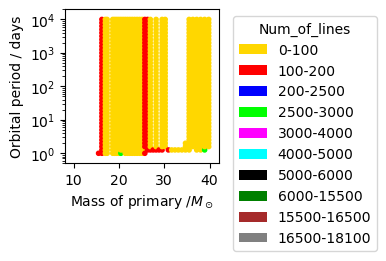

In [10]:
data = pd.read_csv("./BoOST_1.dat", sep=r"\s+")

fig, ax = plt.subplots(figsize=(3, 2))

bins = [0, 100, 200, 2500, 3000, 4000, 5000, 6000, 15500, 16500, 18100]

range_colors = [
    'gold',
    'red',
    'blue',
    'lime',
    'magenta',
    'cyan',
    'black',
    'green',
    'brown',
    'gray'
]

point_colors = pd.cut(
    data['num_of_lines'],
    bins=bins,
    labels=range_colors,
    include_lowest=True
)

mask = data['has_nan']

# False -> faded
ax.scatter(
    data.loc[~mask, 'primary_mass'],
    data.loc[~mask, 'period'],
    color=point_colors[~mask],
    marker='.',
    alpha=0.00001
)

# True -> highlighted
ax.scatter(
    data.loc[mask, 'primary_mass'],
    data.loc[mask, 'period'],
    color=point_colors[mask],
    marker='.',
    alpha=1
)


from matplotlib.patches import Patch

legend_handles = []

for i, color in enumerate(range_colors):

    if bins[i+1] == float('inf'):
        label = f'>{bins[i]}'
    else:
        label = f'{bins[i]}-{bins[i+1]}'

    legend_handles.append(
        Patch(facecolor=color, label=label)
    )

ax.legend(
    handles=legend_handles,
    title='Num_of_lines',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

ax.set_xlabel(r'Mass of primary $/M_\odot$')        # initial (ZAMS) mass
ax.set_ylabel('Orbital period / days')      # final remnant mass
# ax.set_ylim(ymin=1, ymax=10000) ##10000
# ax.set_xlim(xmin=10, xmax=40) ##40

ax.set_box_aspect(1)

# X padding (linear)
ax.set_xlim(10 - 2, 40 + 2)

# Y padding (log scale)
ax.set_yscale('log')
ax.set_ylim(1 / 2, 10000 * 2)

ax.set_xticks([10, 20, 30, 40])
ax.set_yticks([1, 10, 100, 1000, 10000])

plt.show()

ax.set_title('BoOST_run1_num_of_lines_with_mask_false_faded') 


img_title = "Check_BoOST_num_of_lines_with_mask_false_faded"

# save_name = output_img_dir/f"{img_title}.png"
save_name = f"{img_title}.png"

fig.savefig(save_name, bbox_inches="tight")

In [ ]:
bse.f describes all input parameters. 

*
* Set the collision matrix.
*
      CALL instar
*
      label(1) = 'INITIAL '  # start
      label(2) = 'KW CHNGE'  # kw change
      label(3) = 'BEG RCHE'
      label(4) = 'END RCHE'
      label(5) = 'CONTACT '  # Contact system
      label(6) = 'COELESCE'  # Merged (evolv2.f)
      label(7) = 'COMENV  '
      label(8) = 'GNTAGE  '  # determine the age of a giant from its core mass and type (SSE/SSE_gntage.f)
      label(9) = 'NO REMNT' # Binary dissolved by a supernova or tides. (evolv2.f)
      label(10) = 'MAX TIME'
      label(11) = 'DISRUPT '
      label(12) = 'BEG SYMB'
      label(13) = 'END SYMB'
      label(14) = 'BEG BSS' # blue straggler formation. (evolv2.f)
*

evolv2.f >> 4) Now using q_crit = 3.0 for MS-MS Roche systems (previously we 
*    had nothing). This corresponds roughly to R proportional to M^5 
*    which should be true for the majority of the MS (varies from 
*    (M^17 -> M^2). If q > q_crit then contact occurs. 
*    For CHeB primaries we also take q_crit = 3.0 and allow 
*    common-envelope to occur if this is exceeded. 

##Run 2

In [ ]:
data = pd.read_csv("./BoOST_1_run2.dat", sep=r"\s+")

fig, ax = plt.subplots(figsize=(3, 2))

num_false = (data['has_nan'] == True).sum()
total_rows = len(data)

case_colors = {
    True: 'black',
    False: 'yellow'  ## No NaN
}

primary_mass = data['primary_mass']
period = data['period']

colors = data['has_nan'].map(case_colors)
    
ax.scatter(primary_mass , period, color=colors, marker='.')


# Write text on the figure
ax.text(
    1.5, 0.0001,
    f'NaN: {num_false}\nTotal rows: {total_rows}',
    transform=ax.transAxes,
    verticalalignment='bottom',
    
)


ax.set_xlabel(r'Mass of primary $/M_\odot$')        # initial (ZAMS) mass
ax.set_ylabel('Orbital period / days')      # final remnant mass
# ax.set_ylim(ymin=1, ymax=10000) ##10000
# ax.set_xlim(xmin=10, xmax=40) ##40

ax.set_box_aspect(1)

# X padding (linear)
ax.set_xlim(10 - 2, 40 + 2)

# Y padding (log scale)
ax.set_yscale('log')
ax.set_ylim(1 / 2, 10000 * 2)

ax.set_xticks([10, 20, 30, 40])
ax.set_yticks([1, 10, 100, 1000, 10000])

plt.show()

ax.set_title('BoOST_run2') 


img_title = "Check_BoOST_run2"

# save_name = output_img_dir/f"{img_title}.png"
save_name = f"{img_title}.png"

fig.savefig(save_name, bbox_inches="tight")